In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append('../')
from utils import * #only needed for xgboost
from friedman1 import *

import warnings
warnings.filterwarnings("ignore") #just to supress warnings

In [2]:
#Function that returns best params for each pair of (d, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per (target_instances, d), ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col=[0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by=['seed'] + config_cols)

    # aggregate over seeds
    agg = (df.groupby(config_cols, as_index=False)
             .agg(avg_rmse=('rmse', 'mean'),
                  avg_mae=('val_mae', 'mean'),
                  n_seeds=('seed', 'nunique'),
                  d=('d', 'first')))

    # merge back on config_cols only (minimal fix)
    agg = agg.merge(df, on=config_cols, how='left')

    # sort globally by the fields that determine the ranking
    agg = agg.sort_values(by=['d', 'avg_rmse'], ascending=True)

    # select top-k per (target_instances, d)
    topk_df = agg.groupby(['d'], group_keys=False).head(k)

    # final compact output
    topk_d = topk_df[['d', 'avg_rmse', 'rmse', 'mae']]

    return topk_d, agg




In [3]:
#Read data (remove v = 0.05 because we chose not to include it)
data_ttb = pd.read_csv('results/ttb_LS.csv')
data_xgboost = pd.read_csv('results/xgb.csv')
data_xgboost_warmstart = pd.read_csv('results/xgb_warmstart.csv')
data_xgboost_pooled = pd.read_csv('results/xgb_naive.csv')

# Here we make final vizes!

(0.8, 1.9)

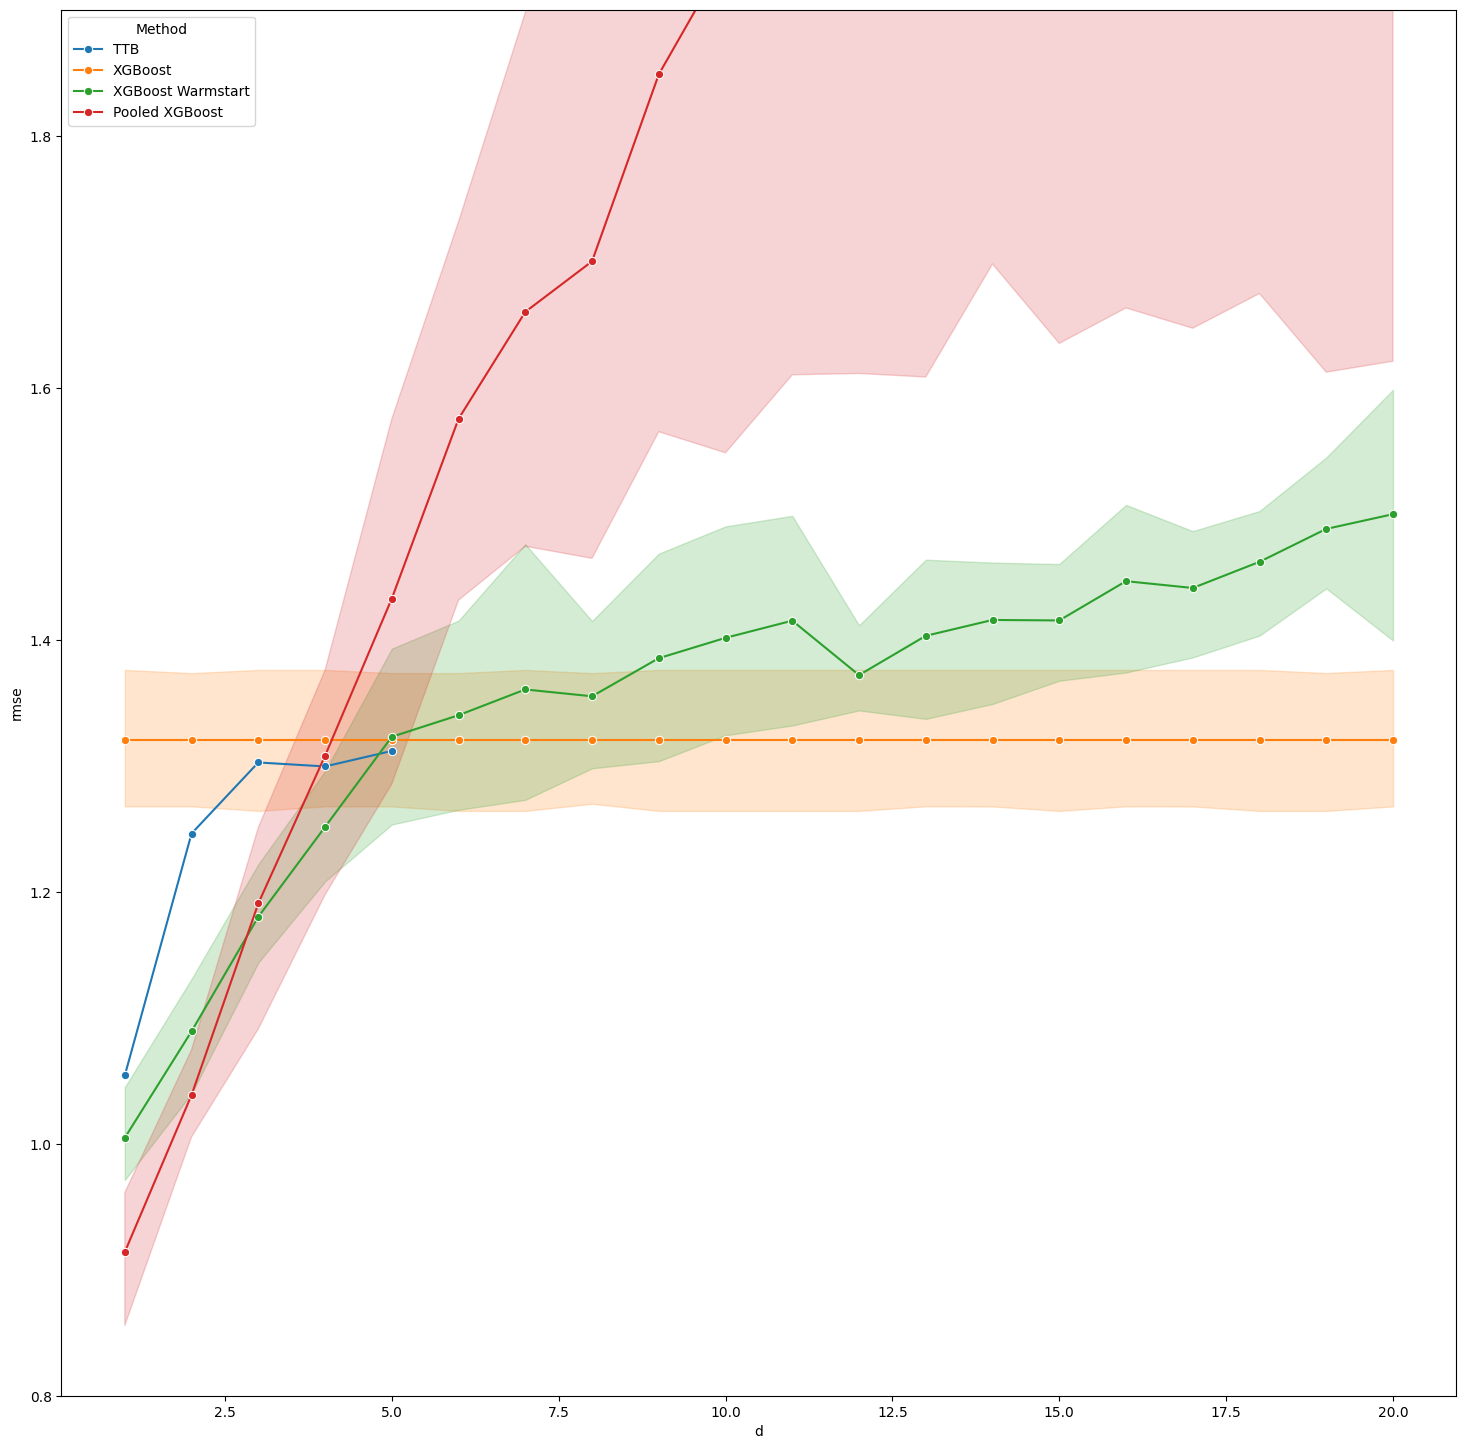

In [11]:

plt.figure(figsize = (18,18))

import matplotlib as mpl

best_ttb, best_ttb_params = topk_per_d_per_method(
    data_ttb,
    ['d', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=1
)
best_ttb['Method'] = 'TTB'

best_xgboost, best_xgboost_params = topk_per_d_per_method(
    data_xgboost,
    ['d', 'v', 'target_tree_size'], k=5
)
best_xgboost['Method'] = 'XGBoost'

best_xgboost_warmstart, best_xgboost_warmstart_params = topk_per_d_per_method(
    data_xgboost_warmstart,
    ['d', 'v', 'target_tree_size'], k=5
)
best_xgboost_warmstart['Method'] = 'XGBoost Warmstart'

best_xgboost_pooled, best_xgboost_pooled_params = topk_per_d_per_method(
    data_xgboost_pooled,
    ['d', 'v', 'target_tree_size'], k=5
)
best_xgboost_pooled['Method'] = 'Pooled XGBoost'


# create new df for viz
df = pd.concat([best_ttb, best_xgboost])
df = pd.concat([df, best_xgboost_warmstart])
df = pd.concat([df, best_xgboost_pooled])
sns.lineplot(data=df, x='d', y='rmse', hue='Method', marker = 'o')
plt.ylim([0.8,1.9])

In [5]:
gh = data_ttb[data_ttb['d'] == 5]
np.min(gh['rmse'])

np.float64(1.3117269889132237)

In [6]:
gh = data_xgboost[(data_xgboost['d'] == 2) & (data_xgboost['seed'] == 904)]
np.min(gh['rmse'])

np.float64(1.3864963756224409)

In [7]:
(1.24 + 1.21 + 1.26 + 1.33 + 1.39) / 5

1.286